In [1]:
import cv2
import numpy as np
import scipy
import matplotlib.pyplot as plt
import os
import time
import copy
def lucas_kanade_optical_flow(video_path,window_size):
  cap = cv2.VideoCapture(video_path)
  if not cap.isOpened():
    print("Error: Could not open video")
  else:
    print("Video opened successfully")
  ret, prev_frame = cap.read()
  if not ret:
    raise Exception("Could not read first frame")
  prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY).astype(np.float64)
  fps = cap.get(cv2.CAP_PROP_FPS)
  print(fps)
  widths = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
  heights = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
  fourcc = cv2.VideoWriter_fourcc(*'XVID')
  out = cv2.VideoWriter(
    'lucas_kanade_output.avi',
    fourcc,
    fps,
    (widths, heights)
  )
  while True:
    ret, curr_frame = cap.read()
    if not ret:
      break
    curr_gray = cv2.cvtColor(curr_frame, cv2.COLOR_BGR2GRAY).astype(np.float64)

    length = curr_gray.shape[0]
    width = curr_gray.shape[1]
    numoflength = int(length/window_size)
    numofwidth = int(width/window_size)
    prev_blur = cv2.GaussianBlur(prev_gray, (5, 5), 0)
    curr_blur = cv2.GaussianBlur(curr_gray, (5, 5), 0)
    prev = copy.deepcopy(prev_blur)
    Ixfinal = cv2.Sobel(prev, cv2.CV_64F, 1, 0, ksize=3)
    Iyfinal = cv2.Sobel(prev, cv2.CV_64F, 0, 1, ksize=3)
    Itfinal = curr_blur - prev_blur
    I_final = []
    v_final = []
    for i in range(numoflength):
      for j in range(numofwidth):
        I_values = []
        Ix = Ixfinal[i*window_size:(i+1)*window_size,j*window_size:(j+1)*window_size]
        Iy = Iyfinal[i*window_size:(i+1)*window_size,j*window_size:(j+1)*window_size]
        It = Itfinal[i*window_size:(i+1)*window_size,j*window_size:(j+1)*window_size]
        time_values = []
        for pi in range(window_size):
          for pj in range(window_size):
            I_value = []
            I_value.append(Ix[pi][pj])
            I_value.append(Iy[pi][pj])
            I_values.append(I_value)
            time_values.append(It[pi][pj])

        I_values = np.array(I_values)
        I_final.append(I_values)
        time_values = (-1) * np.array(time_values)
        v = np.linalg.lstsq(I_values, time_values, rcond=None)[0]
        v_final.append(v)
    I_final = np.array(I_final)
    v_final = np.array(v_final)
    k = 0
    for i in range(numoflength):
      for j in range(numofwidth):
        xcentre = int(j*window_size + window_size/2)
        ycentre = int(i*window_size + window_size/2)
        u = v_final[k][0]
        v = v_final[k][1]
        scale = 12
        x_end = int(xcentre + scale * u)
        y_end = int(ycentre + scale * v)
        cv2.arrowedLine(
           curr_frame,
           (xcentre, ycentre),
           (x_end, y_end),
           (0, 0, 0),   # black
            2,            # thickness
          line_type=cv2.LINE_8,
          tipLength=0.5
        )
        k += 1
    out.write(curr_frame)
    prev_gray = curr_gray
  cap.release()
  out.release()
  return 'lucas_kanade_output.avi'

In [2]:
video_path = "/content/vtest.avi"
output_path = lucas_kanade_optical_flow(video_path,20)

Video opened successfully
10.0


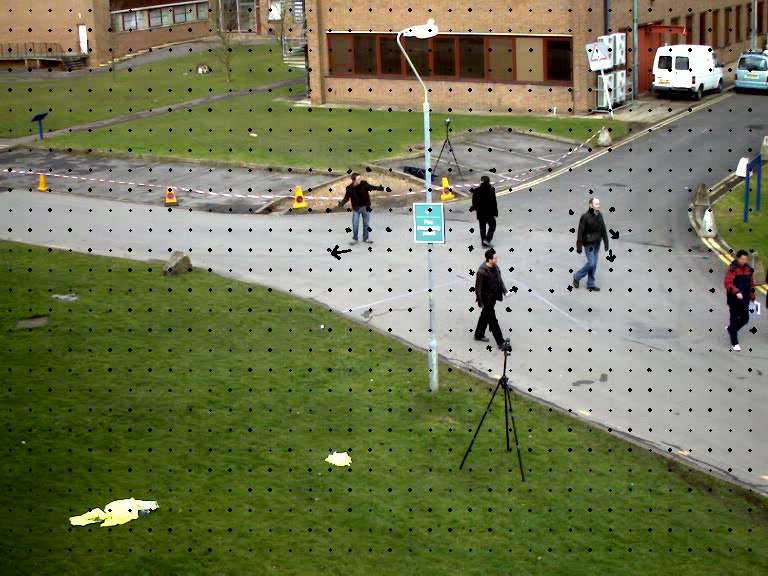

In [ ]:
import cv2
from google.colab.patches import cv2_imshow
from IPython.display import clear_output
import time

cap = cv2.VideoCapture(output_path)


fps = cap.get(cv2.CAP_PROP_FPS)
while True:
    ret, frame = cap.read()

    if not ret:
        break

    clear_output(wait=True)
    cv2_imshow(frame)

    time.sleep(0.005)

cap.release()